# 1. import Necessary Libraries

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,auc,roc_curve
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# 2. import Dataset

In [5]:
claiment_data = pd.read_csv("claiments.csv")
claiment_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


# 3. Data Uderstanding

In [6]:
claiment_data.shape

(1340, 7)

In [7]:
claiment_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [8]:
claiment_data.dropna(inplace=True)

In [9]:
claiment_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [10]:
claiment_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

# 4. Data Preparation 

## 4.1 Data cleaing

In [11]:
claiment_data.dropna(inplace=True)
claiment_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [12]:
claiment_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4.2 Data separate your input and output

In [13]:
x = claiment_data.drop(labels=["CASENUM","ATTORNEY"],axis=1)
x

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [14]:
y = claiment_data["ATTORNEY"]

# 5. Model Building

## 5.1 Model Validation Techniques - Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.20)

## 5.2 K Fold CV

In [98]:
from sklearn.model_selection import KFold,cross_val_score

klov=KFold(n_splits=5,shuffle=True)

cv =cross_val_score(estimator=rand_model,X=x,y=y,cv=klov)
print(cv)
print(cv.mean())

[0.71818182 0.74429224 0.77625571 0.73515982 0.70319635]
0.7354171855541718


In [16]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
674,1.0,1.0,0.0,33.0,5.467
690,0.0,1.0,0.0,5.0,0.315
1238,1.0,1.0,0.0,40.0,0.398
1256,0.0,1.0,1.0,30.0,30.640
618,0.0,1.0,0.0,83.0,0.380
...,...,...,...,...,...
820,0.0,1.0,0.0,40.0,0.310
668,1.0,1.0,0.0,39.0,3.086
574,1.0,1.0,0.0,49.0,6.371
797,1.0,1.0,0.0,69.0,7.610


In [17]:
logistic_model = LogisticRegression()

# 6. Model Traning

In [53]:
grid = GridSearchCV(estimator=rand_model,param_grid={"max_depth":[75,85,100,150]})
grid.fit(X_train,y_train)
print(grid.best_score_)
print(grid.best_params_)

0.6587142857142857
{'max_depth': 75}


In [18]:
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier

In [78]:
rand_model = RandomForestClassifier(n_estimators=85,max_depth=5)

In [79]:
rand_model.fit(X_train,y_train)

,n_estimators,85
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
ada_model = AdaBoostClassifier()

In [20]:
ada_model.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [46]:
dt_model = DecisionTreeClassifier()

In [48]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Grid Search CV(Cross Validation)

In [127]:
dt_model = DecisionTreeClassifier(criterion='gini',max_depth=4)

In [77]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator=rand_model,param_grid={"max_depth":[4,5,6,7,8,9,10],"criterion":['gini','entropy'],"n_estimators":[75,85,100,125]})

grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 85}
0.721474025974026


In [128]:
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# 7. Model Testing

## 7.1 Traning Data

In [80]:
y_pred_train = rand_model.predict(X_train)
y_pred_train

array([0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,

In [81]:
y_pred_test = rand_model.predict(X_test)
y_pred_test

array([1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0])

# 8. Model Evaluation

### 8.1 Traning Data's Evaluation Matrics

In [82]:
print(confusion_matrix(y_train,y_pred_train))

[[363 102]
 [124 287]]


In [83]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.78      0.76       465
           1       0.74      0.70      0.72       411

    accuracy                           0.74       876
   macro avg       0.74      0.74      0.74       876
weighted avg       0.74      0.74      0.74       876



#### ROC Curve -- Receiver Operating Charateristics 

##### AUC -- Area Under this curve

0.7394709991366455


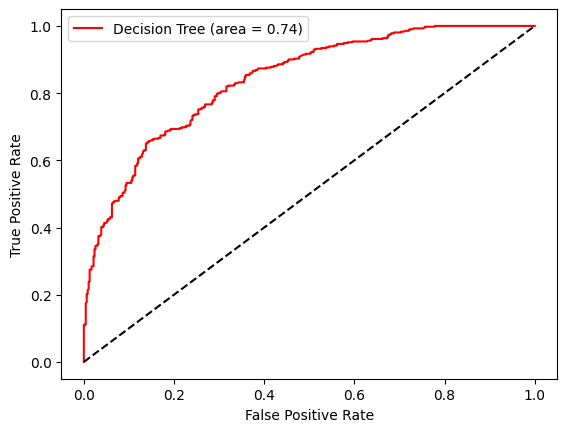

In [84]:
fpr, tpr, thresholds = roc_curve(y_train, rand_model.predict_proba(X_train)[:,1])

auc = roc_auc_score(y_train, y_pred_train)
print(auc)

plt.plot(fpr, tpr, color="red", label="Decision Tree (area = %0.2f)" % auc)
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [85]:
accuracy_score(y_train,y_pred_train)

0.7420091324200914

### 8.2 Test Data's Evaluation Matrics

In [86]:
accuracy_score(y_test,y_pred_test)

0.75

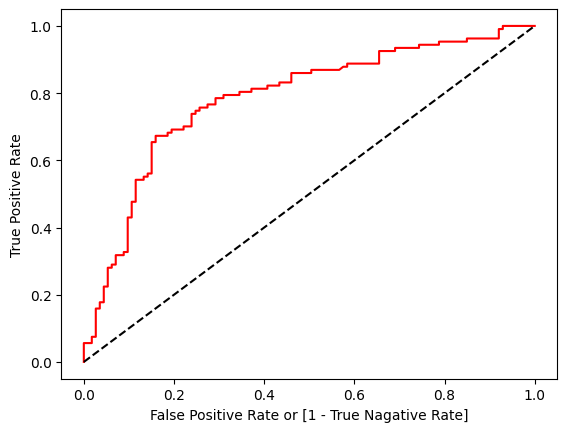

In [87]:
fpr,tpr,thesholds = roc_curve(y_test,rand_model.predict_proba (X_test)[:,1])
auc=roc_auc_score(y_test,y_pred_test)

plt.plot(fpr,tpr,color="red",label="logit model (area = %0.1f)"%auc)
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate or [1 - True Nagative Rate]")
plt.ylabel("True Positive Rate")
plt.show()

In [88]:
confusion_matrix(y_test,y_pred_test)

array([[92, 21],
       [34, 73]])

In [89]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.73      0.81      0.77       113
           1       0.78      0.68      0.73       107

    accuracy                           0.75       220
   macro avg       0.75      0.75      0.75       220
weighted avg       0.75      0.75      0.75       220



In [90]:
accuracy_score(y_test,y_pred_test)

0.75

# 9. Model Deployemnt

In [31]:
from pickle import dump

In [36]:
dump(logistic_model,file = open("Claiment_data.pkl","wb"))

In [37]:
from pickle import load

In [44]:
claiment_data_pl = load(file=open("Claiment_data.pkl",mode="rb"))
claiment_data_pl

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
claiment_data_pl.predict(x)

array([0, 1, 1, ..., 1, 0, 1], shape=(1096,))

In [1]:
pip install xgBoost

     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.3/101.7 MB 7.2 MB/s eta 0:00:15
     ---------------------------------------- 0.8/101.7 MB 8.7 MB/s eta 0:00:12
     ---------------------------------------- 1.2/101.7 MB 9.6 MB/s eta 0:00:11
     ---------------------------------------- 1.3/101.7 MB 8.9 MB/s eta 0:00:12
      --------------------------------------- 1.9/101.7 MB 8.7 MB/s eta 0:00:12
      --------------------------------------- 2.1/101.7 MB 9.0 MB/s eta 0:00:12
     - -------------------------------------- 2.8/101.7 MB 8.8 MB/s eta 0:00:12
     - -------------------------------------- 3.2/101.7 MB 8.8 MB/s eta 0:00:12
     - -------------------------------------- 3.6/101.7 MB 8.8 MB/s eta 0:00:12
     - -------------------------------------- 4.0/101.7 MB 8.4 MB/s eta 0:00:12
     - -------------------------------------- 4.3/101.7 MB 8.7 MB/s eta 0:00:12
     - -------------------------------------- 4


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
